In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r'C:\Users\user\my_snippet\DataSets\coffee_shop.csv')
df['datetime'] = pd.to_datetime(df['transaction_date']+ " " +df['transaction_time'],format='%d-%m-%Y %H:%M:%S')
df['hour'] = df['datetime'].dt.hour
df['revenue'] = df['unit_price'] * df['transaction_qty']


revenue                                                    \
hour                     6         7         8         9         10        11   
product_category                                                                
Bakery              2677.95   7948.44  10417.84  10523.91  10982.50   5612.06   
Branded              406.00   1754.00   2098.00   2035.00   1745.00    532.00   
Coffee              7811.95  23579.90  30579.85  31014.85  33297.10  18188.15   
Coffee beans         874.45   3602.20   5444.75   7353.25   7608.70   3295.20   
Drinking Chocolate  2770.50   6507.25   8166.00   7787.50   8070.50   4853.75   
Flavours             430.40    985.60   1224.80   1176.00   1532.80    427.20   
Loose Tea            614.45   1229.05   1403.85   2072.15   1608.45    457.95   
Packaged Chocolate   258.52    680.18    605.78    383.82    799.79    248.88   
Tea                 6056.05  17239.85  22759.00  22823.05  23028.55  12703.95   

                                                                      \
hour                      12        13        14        15        16   
product_category                                                       
Bakery               4180.44   4421.08   4740.46   4739.70   4661.42   
Branded               470.00    966.00    428.00   1001.00    504.00   
Coffee              16162.90  16620.95  16725.35  16737.05  16861.55   
Coffee beans         1384.15   1566.65   1573.95   1573.30   1782.65   
Drinking Chocolate   4416.50   4415.00   4637.50   4456.25   4394.75   
Flavours              333.60    339.20    356.80    312.00    394.40   
Loose Tea             476.50    458.55    471.30    423.25    595.35   
Packaged Chocolate    101.60    260.12    238.88    200.40    127.18   
Tea                 12667.10  11319.90  12132.50  12290.15  11801.45   

                                                          
hour                      17        18        19      20  
product_category                                          
Bakery               4445.21   3650.94   2997.82  315.87  
Branded               522.00    468.00    622.00   56.00  
Coffee              16527.65  14241.20  10630.15  973.85  
Coffee beans         1018.75   1310.05   1427.20  270.00  
Drinking Chocolate   4775.75   3319.00   3506.75  339.00  
Flavours              351.20    277.60    204.80   62.40  
Loose Tea             496.90    414.50    472.35   19.00  
Packaged Chocolate    191.60     83.86    150.91   76.12  
Tea                 11805.25  10521.05   8434.70  823.40

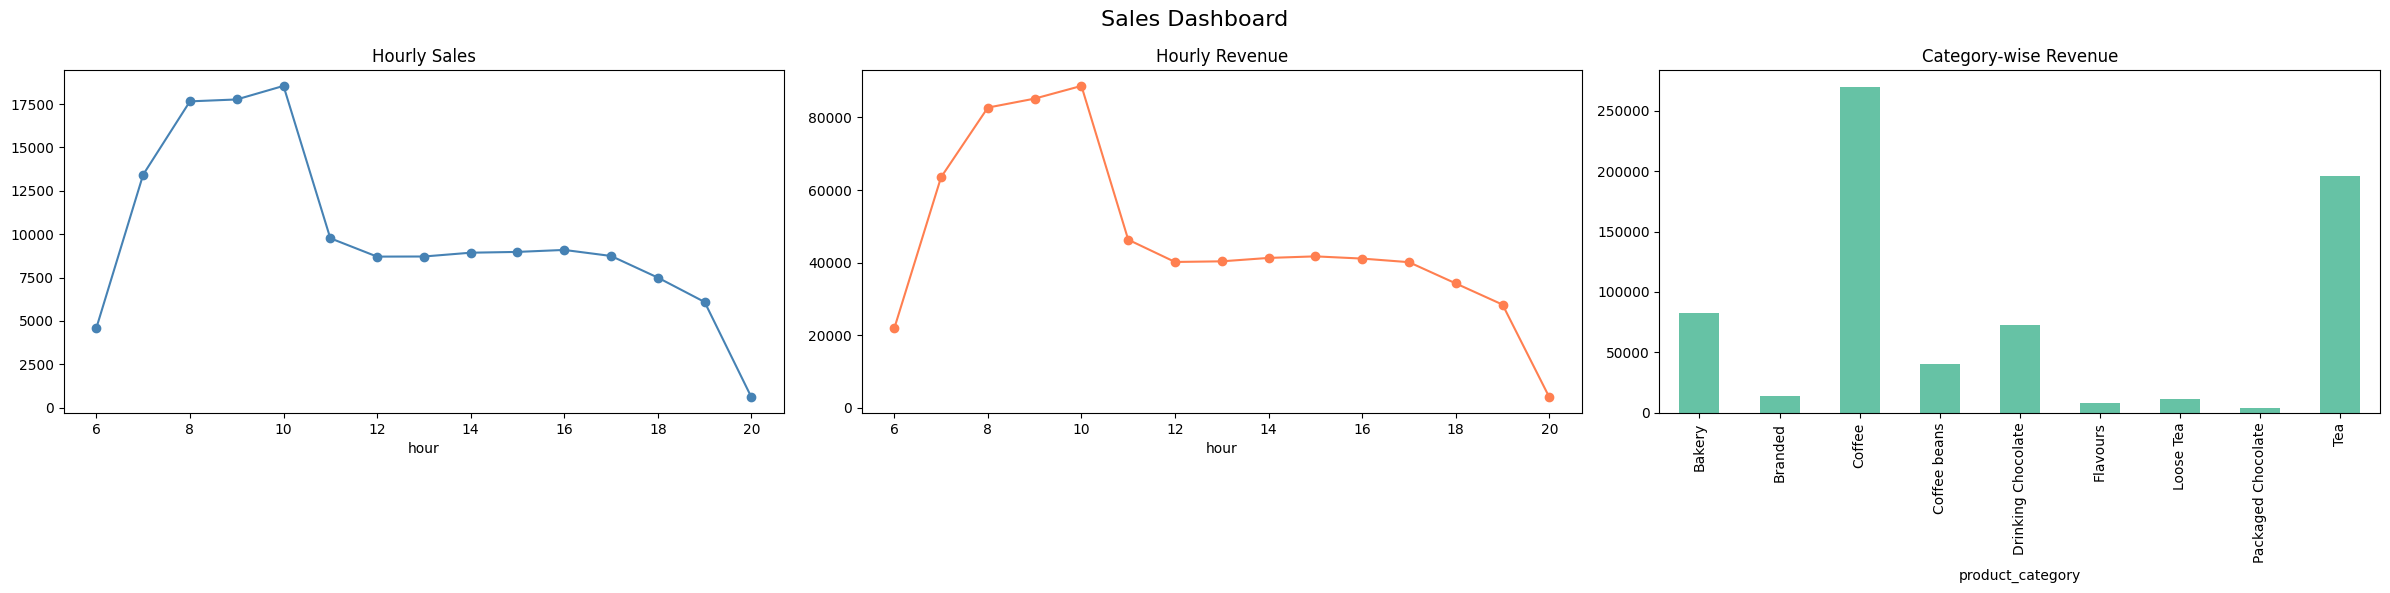

In [28]:
#28 a multi-panel dashboard (hourly sales + revenue + category split)
fig,axes = plt.subplots(1,3,figsize=(24,6))
df.groupby('hour')['transaction_id'].nunique().plot(ax=axes[0],
                                                    marker='o',
                                                    kind='line',
                                                    title='Hourly Sales',
                                                    color='steelblue')

df.groupby('hour')['revenue'].sum().plot(ax=axes[1],kind='line',
                                         marker='o',
                                         title='Hourly Revenue',
                                         color='coral')

df.groupby('product_category')['revenue'].sum().plot(ax=axes[2],kind='bar',
                                                     title='Category-wise Revenue',
                                                     colormap='Set2')
plt.suptitle('Sales Dashboard',fontsize=16)
plt.tight_layout()

In [ ]:
#29 Identify seasonal patterns (if time span allows) using rolling averages.

Text(0.5, 1.0, 'Revenue Trend with Rolling Average')

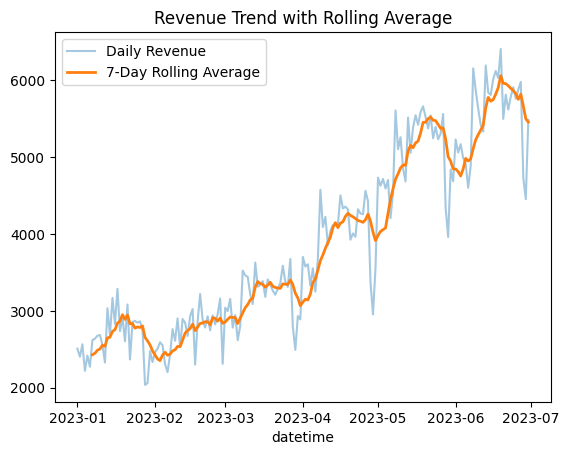

In [57]:
#30 Identify seasonal patterns (if time span allows) using rolling averages.
#daile revenue with rolling average
daily_revenue = df.groupby(df['datetime'].dt.date)['revenue'].sum()
daily_revenue.plot(label='Daily Revenue',alpha=0.4)
daily_revenue.rolling(window=7).mean().plot(label='7-Day Rolling Average',
                                            linewidth=2)
plt.legend()
plt.title('Revenue Trend with Rolling Average')

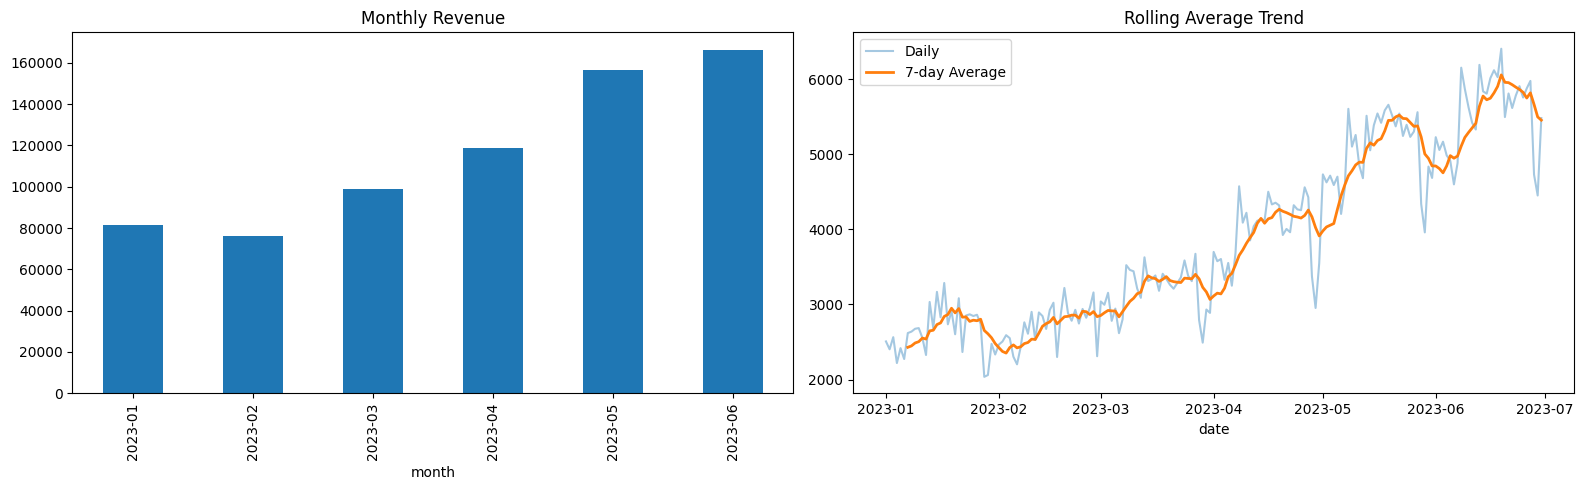

In [59]:
# both together fully answers the question
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df['date'] = df['datetime'].dt.date
# panel 1 - monthly pattern
df.groupby('month')['revenue'].sum().plot(
    kind='bar', ax=axes[0], title='Monthly Revenue')

# panel 2 - rolling average trend
daily_revenue = df.groupby('date')['revenue'].sum()
daily_revenue.plot(ax=axes[1], alpha=0.4, label='Daily')
daily_revenue.rolling(window=7).mean().plot(
    ax=axes[1], linewidth=2, label='7-day Average')
axes[1].set_title('Rolling Average Trend')
axes[1].legend()

plt.tight_layout()

In [61]:
pt = df.pivot_table(index='product_category',
                    columns='store_location',
                    values='revenue',
                    aggfunc='sum')
# rank per column (store) ✅
pt_ranked = pt.rank(ascending=False)  # rank 1 = highest revenue

# plt.figure(figsize=(10,6))
# sns.heatmap(pt_ranked,
#             cmap='RdYlGn_r',    # green=rank1, red=low rank ✅
#             annot=pt.values,    # show actual revenue not rank numbers
#             fmt='.0f',
#             linewidths=0.5,
#             linecolor='white')

# plt.title('Ranked Product Performance Across Stores')
# plt.xlabel('Store Location')
# plt.ylabel('Product Category')
# plt.tight_layout()


In [65]:
pt_ranked = df.pivot_table(index='product_category',
                    columns='store_location',
                    values='revenue',
                    aggfunc='sum').rank(ascending=False)


In [66]:
pt_ranked

store_location,Astoria,Hell's Kitchen,Lower Manhattan
product_category,,,
Bakery,3.0,3.0,3.0
Branded,6.0,8.0,6.0
Coffee,1.0,1.0,1.0
Coffee beans,5.0,5.0,5.0
Drinking Chocolate,4.0,4.0,4.0
Flavours,8.0,7.0,7.0
Loose Tea,7.0,6.0,8.0
Packaged Chocolate,9.0,9.0,9.0
Tea,2.0,2.0,2.0
